# Shift

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ae483.tools import *
from ae483.mytools import *

Load data from a flight in which the drone took off, moved in a square, and landed.

In [3]:
raw_data_drone, raw_data_mocap, raw_data_bodies = load_hardware_data('square.json')

Resample drone data.

In [4]:
data_drone = resample_data_drone(raw_data_drone, t_min_offset=0., t_max_offset=0.)

t = data_drone['time']
x_drone = data_drone['stateEstimate.x']
y_drone = data_drone['stateEstimate.y']
z_drone = data_drone['stateEstimate.z']
psi_drone = np.deg2rad(data_drone['stateEstimate.yaw'])
theta_drone = - np.deg2rad(data_drone['stateEstimate.pitch'])
phi_drone = np.deg2rad(data_drone['stateEstimate.roll'])

Resample mocap data with a **zero time shift**, apply coordinate transformation, and plot the result.

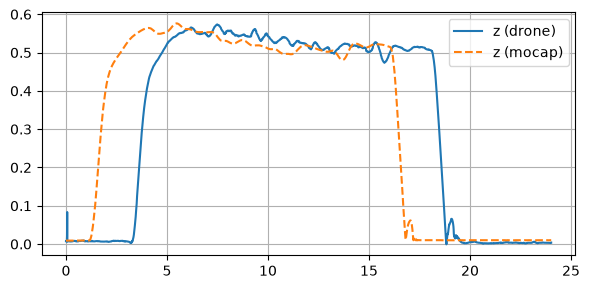

In [5]:
# Resample mocap data with a zero time shift
resampled_data_mocap = resample_data_mocap(raw_data_mocap, t, t_shift=0.)

# Apply coordinate transformation to resampled mocap data
transformed_data_mocap = transform_data_mocap(resampled_data_mocap)

# Get and plot the z estimate from the time-shifted and transformed mocap data
z_mocap = transformed_data_mocap['z']
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Resample mocap data with a **non-zero time shift**, apply coordinate transformation, and plot the result.

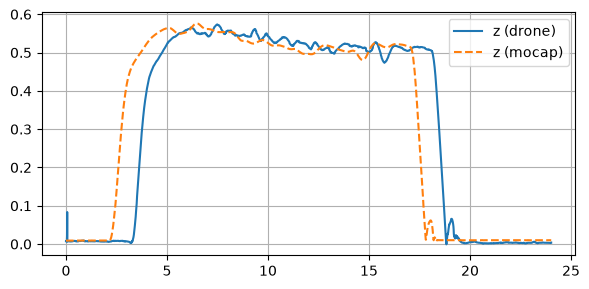

In [6]:
# Resample mocap data with a non-zero time shift
resampled_data_mocap = resample_data_mocap(raw_data_mocap, t, t_shift=1.)

# Apply coordinate transformation to resampled mocap data
transformed_data_mocap = transform_data_mocap(resampled_data_mocap)

# Get and plot the z estimate from the time-shifted and transformed mocap data
z_mocap = transformed_data_mocap['z']
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Resample mocap data with a **rough guess at the time shift best aligns it** with drone data, apply coordinate transformation, and plot the result.

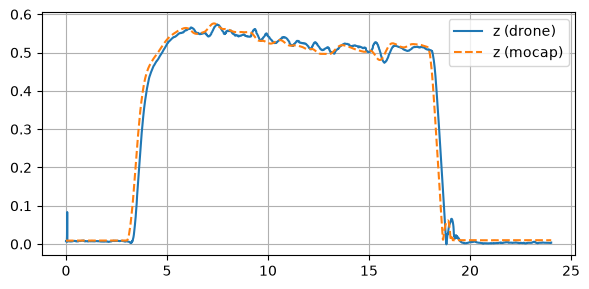

In [7]:
# Get a rough guess at the time shift that would align mocap data with drone data
t_shift_guess = rough_time_shift(raw_data_mocap, t, z_drone)

# Resample mocap data with this rough guess at the time shift
resampled_data_mocap = resample_data_mocap(raw_data_mocap, t, t_shift=t_shift_guess)

# Apply coordinate transformation to resampled mocap data
transformed_data_mocap = transform_data_mocap(resampled_data_mocap)

# Get and plot the z estimate from the time-shifted and transformed mocap data
z_mocap = transformed_data_mocap['z']
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t, z_drone, label='z (drone)')
ax.plot(t, z_mocap, '--', label='z (mocap)')
ax.legend()
ax.grid()

Define parameters to use when searching for a time shift that more precisely aligns mocap data with drone data.

In [8]:
# Choose whether to apply the transform that aligns mocap data in space
do_transform = True

# Choose search interval
t_shift_rng = 1.

# Choose resolution
t_shift_res = 0.05

# Choose how many seconds to ignore (i.e., delete) at the start of the mocap data
t_min_offset = 0.

Get a rough guess at the time shift (just like before, but now with `t_min_offset`).

In [9]:
t_shift_guess = rough_time_shift(raw_data_mocap, t, z_drone, t_min_offset=t_min_offset)

Find the root-mean-square-error (RMSE) for a range of time shifts sampled around the rough guess.

In [ ]:
# Create an array of time shifts over which to searchs
t_shifts = np.linspace(
    t_shift_guess - t_shift_rng,                        # lower bound
    t_shift_guess + t_shift_rng,                        # upper bound
    int(1 + np.ceil((2 * t_shift_rng) / t_shift_res)),  # number of samples
)

# Print a warning if computation time is likely to be long
if len(t_shifts) > 50:
    print(f'========================================================================')
    print(f'WARNING (sync_data_mocap)\n')
    print(f'Searching the interval\n')
    print(f'  t_shift_bnds=[{min(t_shifts):4.2f}, {max(t_shifts):4.2f}]\n')
    print(f'with the resolution\n')
    print(f'  t_shift_res={t_shift_res:4.2f}\n')
    print(f'means computing RMSE for {len(t_shifts)} possible time shifts, which is likely')
    print(f'to be slow. You may want to decrease the size of the search interval')
    print(f'or increase the resolution.')
    print(f'========================================================================\n')

# Create an array to hold the RMSE for each time shift
RMSEs = np.empty_like(t_shifts)

# Find the RMSE for each time shift
for i, t_shift in enumerate(t_shifts):
    # Resample mocap data with time shift
    resampled_data_mocap = resample_data_mocap(
        raw_data_mocap,
        t,
        t_shift=t_shift,
        t_min_offset=t_min_offset,
    )

    # Transform mocap data
    if do_transform:
        transformed_data_mocap = transform_data_mocap(resampled_data_mocap)
    else:
        transformed_data_mocap = resampled_data_mocap

    # Get z estimate from mocap data
    z_mocap = transformed_data_mocap['z']

    # Find RMSE between z_mocap and z_drone
    RMSEs[i] = np.sqrt(np.mean((z_mocap - z_drone)**2))

Plot the RMSE for each of the sampled time shifts.

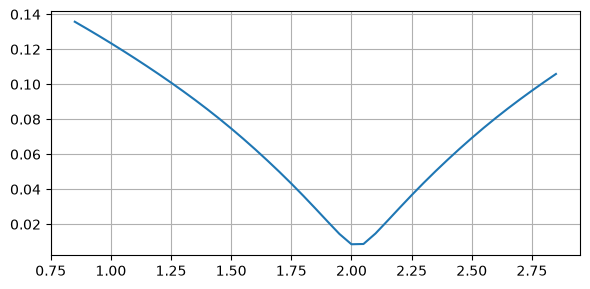

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.plot(t_shifts, RMSEs)
ax.grid()

Find the time shift that gives the minimum RMSE.

(Please do **NOT** find `i_min`, `RMSE_min`, and `t_shift_min` by inspection from the plots. Instead, write code that finds each of these quantities in an automated way, so that you can use it for any data you collect, not just for the data you are looking at in this example.)

In [12]:
# Find the index of the minimum RMSE
i_min = np.argmin(RMSEs)    # <-- FIXME

# Find the minimum RMSE
RMSE_min = min(RMSEs)       # <-- FIXME

# Find the time shift that gives the minimum RMSE
t_shift_min = t_shifts[i_min]    # <-- FIXME

# Store result for later comparison
t_shift_min_stored = t_shift_min

Plot the RMSE for a range of time shifts again, this time showing the minimum.

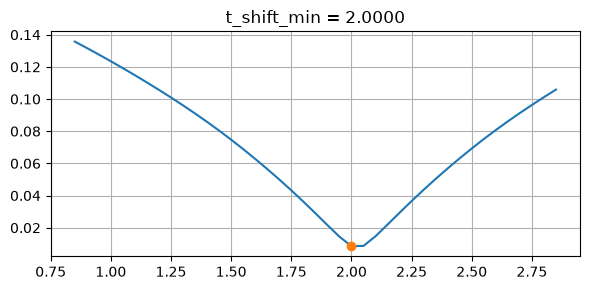

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
ax.set_title(f't_shift_min = {t_shift_min:.4f}')
ax.plot(t_shifts, RMSEs)
ax.plot(t_shift_min, RMSE_min, '.', markersize=12)
ax.grid()

Define a function that finds the time shift that best aligns transformed mocap data with drone data, given a rough guess.

In [16]:
def precise_time_shift(raw_data_mocap, t, z_drone, t_shift_guess,
                       do_transform=True, t_min_offset=0.,
                       t_shift_rng=1., t_shift_res=0.05):
    """
    Find a value of t_shift that precisely aligns mocap data with
    drone data by sampling candidate values in the interval

        [t_shift_guess - t_shift_rng, t_shift_guess + t_shift_rng]
    
    at the resolution t_shift_res and returning the value that
    produces the minimum RMSE between z_drone and z_mocap.
    """
    
    # Create an array of time shifts over which to searchs
    t_shifts = np.linspace(
    t_shift_guess - t_shift_rng,                        # lower bound
    t_shift_guess + t_shift_rng,                        # upper bound
    int(1 + np.ceil((2 * t_shift_rng) / t_shift_res)),  # number of samples
    )

    # Print a warning if computation time is likely to be long
    if len(t_shifts) > 50:
        print(f'========================================================================')
        print(f'WARNING (sync_data_mocap)\n')
        print(f'Searching the interval\n')
        print(f'  t_shift_bnds=[{min(t_shifts):4.2f}, {max(t_shifts):4.2f}]\n')
        print(f'with the resolution\n')
        print(f'  t_shift_res={t_shift_res:4.2f}\n')
        print(f'means computing RMSE for {len(t_shifts)} possible time shifts, which is likely')
        print(f'to be slow. You may want to decrease the size of the search interval')
        print(f'or increase the resolution.')
        print(f'========================================================================\n')

    # Create an array to hold the RMSE for each time shift
    RMSEs = np.empty_like(t_shifts)

    # Find the RMSE for each time shift
    for i, t_shift in enumerate(t_shifts):
        # Resample mocap data with time shift
        resampled_data_mocap = resample_data_mocap(
            raw_data_mocap,
            t,
            t_shift=t_shift,
            t_min_offset=t_min_offset,
        )

        # Transform mocap data
        if do_transform:
            transformed_data_mocap = transform_data_mocap(resampled_data_mocap)
        else:
            transformed_data_mocap = resampled_data_mocap

        # Get z estimate from mocap data
        z_mocap = transformed_data_mocap['z']

        # Find RMSE between z_mocap and z_drone
        RMSEs[i] = np.sqrt(np.mean((z_mocap - z_drone)**2))

    # Find the index of the minimum RMSE
    i_min = np.argmin(RMSEs)    

    # Find the minimum RMSE
    RMSE_min = min(RMSEs)      

    # Find the time shift that gives the minimum RMSE
    t_shift_min = t_shifts[i_min]   

    # Store result for later comparison
    t_shift_min_stored = t_shift_min
        


    # FIXME - your code here, to...
    #   1) Create an array with a range of time shifts over which to search
    #   2) Print a warning if computation time is likely to be long
    #   3) Create an array to hold the RMSE for each time shift
    #   4) Find the RMSE for each time shift
    #   5) Find the index of the minimum RMSE
    #   6) Find the minimum RMSE
    #   7) Find the time shift that gives the minimum RMSE
    
    # Return the result
    return t_shift_min

Apply this function with the same parameters as before and verify that it produces the same result as before.

In [17]:
t_shift_min = precise_time_shift(
    raw_data_mocap,
    t,
    z_drone,
    t_shift_guess=t_shift_guess,  # <-- rough guess at time shift
    do_transform=do_transform,    # <-- whether to align mocap data in space
    t_min_offset=t_min_offset,    # <-- how many seconds of mocap data to delete at the start
    t_shift_rng=t_shift_rng,      # <-- range of time shifts over which to search
    t_shift_res=t_shift_res,      # <-- resolution at which to sample time shifts in the range
)

print(f't_shift_min (old): {t_shift_min_stored:.4f}')
print(f't_shift_min (new): {t_shift_min:.4f}')
assert(np.isclose(t_shift_min, t_shift_min_stored))

t_shift_min (old): 2.0000
t_shift_min (new): 2.0000


Define a function to synchronize mocap data with drone data in space and time.

In [18]:
def sync_data_mocap(raw_data_mocap, t, z_drone,
                    do_transform=True, t_min_offset=0.,
                    t_shift_rng=1., t_shift_res=0.05):

    # Get rough guess at time shift
    t_shift_guess = rough_time_shift(
        raw_data_mocap,
        t,
        z_drone,
        t_min_offset=t_min_offset,
    )

    # Refine the rough guess to get the time shift that
    # minimizes RMSE between z_drone and z_mocap
    t_shift_min = precise_time_shift(
        raw_data_mocap,
        t,
        z_drone,
        t_shift_guess=t_shift_guess,
        do_transform=do_transform,
        t_min_offset=t_min_offset,
        t_shift_rng=t_shift_rng,
        t_shift_res=t_shift_res,
    )

    # Resample mocap data with this time shift
    resampled_data_mocap = resample_data_mocap(
        raw_data_mocap,
        t,
        t_shift=t_shift_min,
        t_min_offset=t_min_offset,
    )
    
    # Transform mocap data
    if do_transform:
        transformed_data_mocap = transform_data_mocap(resampled_data_mocap)
    else:
        transformed_data_mocap = resampled_data_mocap

    # Return the result
    return transformed_data_mocap

Apply synchronization to mocap data. (The parameters may be different from what you were using before. They are yours to choose.)

In [19]:
data_mocap = sync_data_mocap(
    raw_data_mocap,
    t,
    z_drone,
    do_transform=True,      # <-- whether to align mocap data in space
    t_min_offset=0.,        # <-- how many seconds of mocap data to delete at the start
    t_shift_rng=1.,         # <-- range of time shifts over which to search
    t_shift_res=0.05,       # <-- resolution at which to sample time shifts in the range
)

x_mocap = data_mocap['x']
y_mocap = data_mocap['y']
z_mocap = data_mocap['z']
psi_mocap = data_mocap['yaw']
theta_mocap = data_mocap['pitch']
phi_mocap = data_mocap['roll']

Plot all data.

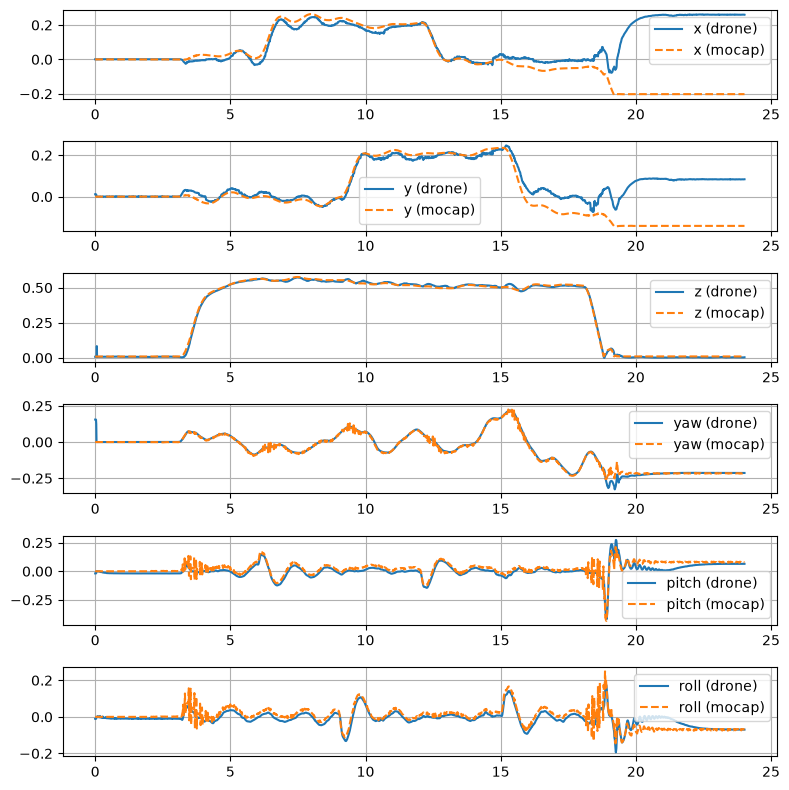

In [20]:
fig, (ax_x, ax_y, ax_z, ax_psi, ax_theta, ax_phi) = plt.subplots(6, 1, figsize=(8, 8), tight_layout=True)

ax_x.plot(t, x_drone, label='x (drone)')
ax_x.plot(t, x_mocap, '--', label='x (mocap)')
ax_x.legend()
ax_x.grid()

ax_y.plot(t, y_drone, label='y (drone)')
ax_y.plot(t, y_mocap, '--', label='y (mocap)')
ax_y.legend()
ax_y.grid()

ax_z.plot(t, z_drone, label='z (drone)')
ax_z.plot(t, z_mocap, '--', label='z (mocap)')
ax_z.legend()
ax_z.grid()

ax_psi.plot(t, psi_drone, label='yaw (drone)')
ax_psi.plot(t, psi_mocap, '--', label='yaw (mocap)')
ax_psi.legend()
ax_psi.grid()

ax_theta.plot(t, theta_drone, label='pitch (drone)')
ax_theta.plot(t, theta_mocap, '--', label='pitch (mocap)')
ax_theta.legend()
ax_theta.grid()

ax_phi.plot(t, phi_drone, label='roll (drone)')
ax_phi.plot(t, phi_mocap, '--', label='roll (mocap)')
ax_phi.legend()
ax_phi.grid()